In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, gc, joblib, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Sel 2 — Load Hasil 3 Model

In [3]:
base = "/content/drive/MyDrive/Colab Notebooks"
print("Memulai ekstraksi file zip...")

# Ekstrak model AE-MLP
ae_zip = os.path.join(base, "model_AE_MLP (1).zip")
if os.path.exists(ae_zip):
    with zipfile.ZipFile(ae_zip, 'r') as zf:
        zf.extractall(os.path.join(base, "models", "model_AE_MLP"))
    print("AE-MLP extracted.")
else:
    print("File model_AE_MLP (1).zip tidak ditemukan.")

# Ekstrak model MLP
mlp_zip = os.path.join(base, "model_MLP (1).zip")
if os.path.exists(mlp_zip):
    with zipfile.ZipFile(mlp_zip, 'r') as zf:
        zf.extractall(os.path.join(base, "models", "model_MLP"))
    print("MLP extracted.")
else:
    print("File model_MLP (1).zip tidak ditemukan.")

# Ekstrak model LightGBM
lgbm_zip = os.path.join(base, "model_LightGBM (1).zip")
if os.path.exists(lgbm_zip):
    with zipfile.ZipFile(lgbm_zip, 'r') as zf:
        zf.extractall(os.path.join(base, "models", "model_LightGBM"))
    print("LightGBM extracted.")
else:
    print("File model_LightGBM (1).zip tidak ditemukan.")

# Ekstrak dataset CIC-IDS2017
data_zip = os.path.join(base, "MachineLearningCSV.zip")
if os.path.exists(data_zip):
    with zipfile.ZipFile(data_zip, 'r') as zf:
        zf.extractall(os.path.join(base, "MachineLearningCSV"))
    print("CIC-IDS2017 dataset extracted.")
else:
    print("File MachineLearningCSV.zip tidak ditemukan.")

Memulai ekstraksi file zip...
AE-MLP extracted.
MLP extracted.
LightGBM extracted.
CIC-IDS2017 dataset extracted.


In [4]:
MODEL_AE_PATH = os.path.join(base, "models", "model_AE_MLP")
MODEL_MLP_PATH = os.path.join(base, "models", "model_MLP")
MODEL_LGBM_PATH = os.path.join(base, "models", "model_LightGBM")
BASE = os.path.join(base, "MachineLearningCSV", "MachineLearningCVE")

print("\nPaths:")
print("  AE-MLP:", MODEL_AE_PATH)
print("  MLP:", MODEL_MLP_PATH)
print("  LightGBM:", MODEL_LGBM_PATH)
print("  CIC-IDS2017 CSV:", BASE)


Paths:
  AE-MLP: /content/drive/MyDrive/Colab Notebooks/models/model_AE_MLP
  MLP: /content/drive/MyDrive/Colab Notebooks/models/model_MLP
  LightGBM: /content/drive/MyDrive/Colab Notebooks/models/model_LightGBM
  CIC-IDS2017 CSV: /content/drive/MyDrive/Colab Notebooks/MachineLearningCSV/MachineLearningCVE


In [5]:
def load_if_exists(path):
    if os.path.exists(path):
        return joblib.load(path) if path.endswith('.pkl') or path.endswith('.joblib') else None
    else:
        print(f"File tidak ditemukan: {path}")
        return None

# AE-MLP
print("\nLoading AE+MLP models...")
ae_model = tf.keras.models.load_model(os.path.join(MODEL_AE_PATH, "ae_model_final.h5"), compile=False)
encoder = tf.keras.models.load_model(os.path.join(MODEL_AE_PATH, "ae_encoder_final.h5"), compile=False)
mlp_ae = tf.keras.models.load_model(os.path.join(MODEL_AE_PATH, "ae_mlp_final.h5"), compile=False)
thr_ae_file = os.path.join(MODEL_AE_PATH, "threshold_ae_mlp.pkl")
THR_AE = joblib.load(thr_ae_file) if os.path.exists(thr_ae_file) else 0.72
if isinstance(THR_AE, dict):
    THR_AE = THR_AE.get('threshold', 0.72)
print(f"THR_AE = {THR_AE:.4f}")

# MLP
print("Loading MLP...")
mlp_std = tf.keras.models.load_model(os.path.join(MODEL_MLP_PATH, "mlp_model_final.h5"), compile=False)
thr_mlp_file = os.path.join(MODEL_MLP_PATH, "threshold_mlp.pkl")
THR_MLP = joblib.load(thr_mlp_file) if os.path.exists(thr_mlp_file) else 0.87
if isinstance(THR_MLP, dict):
    THR_MLP = THR_MLP.get('threshold', 0.87)
print(f"THR_MLP = {THR_MLP:.4f}")

# LightGBM
print("Loading LightGBM...")
lgbm = joblib.load(os.path.join(MODEL_LGBM_PATH, "lgbm_model_final.joblib"))
thr_lgbm_file = os.path.join(MODEL_LGBM_PATH, "threshold_lgbm.pkl")
THR_LGBM = joblib.load(thr_lgbm_file) if os.path.exists(thr_lgbm_file) else 0.68
if isinstance(THR_LGBM, dict):
    THR_LGBM = THR_LGBM.get('threshold', 0.68)
print(f"THR_LGBM = {THR_LGBM:.4f}")

scaler_path = os.path.join(MODEL_AE_PATH, "scaler.pkl")
feature_names_path = os.path.join(MODEL_AE_PATH, "feature_names.pkl")
if os.path.exists(scaler_path) and os.path.exists(feature_names_path):
    qt = joblib.load(scaler_path)
    with open(feature_names_path, "rb") as f:
        features_18 = joblib.load(f)
    print(f"Scaler dan {len(features_18)} feature names dimuat.")
else:
    print("File scaler.pkl atau feature_names.pkl tidak ditemukan.")


Loading AE+MLP models...
THR_AE = 0.7200
Loading MLP...
THR_MLP = 0.8700
Loading LightGBM...
THR_LGBM = 0.6800
Scaler dan 38 feature names dimuat.


In [10]:
def extract_latent_and_error(X, batch_size=256):
    X_pred = ae_model.predict(X, batch_size=batch_size, verbose=0)
    Z = encoder.predict(X, batch_size=batch_size, verbose=0)
    err = np.mean((X - X_pred) ** 2, axis=1, keepdims=True)
    return np.concatenate([Z, err], axis=1).astype('float32')

def test_all_models(X_scaled, label):
    n = len(X_scaled)
    print(f'\n{"="*65}')
    print(f' ZERO-DAY TEST: {label} (n={n})')
    print(f' Dataset: CICIDS2017 — tidak ada di training CICIDS2018')
    print('='*65)
    print(f'{"Model":<15} {"DR (%)":>10} {"Mean P(Attack)":>15} {"Recon Error":>13}')
    print('-'*57)
    res = {}

    Z_ae = extract_latent_and_error(X_scaled)
    probs_ae = mlp_ae.predict(Z_ae, batch_size=256, verbose=0).ravel()
    pred_ae = (probs_ae > THR_AE).astype(int)
    dr_ae = pred_ae.mean() * 100
    err_ae = Z_ae[:, 8].mean()
    print(f'{"AE+MLP":<15} {dr_ae:>10.2f}% {probs_ae.mean():>15.4f} {err_ae:>13.6f}')
    res['ae_mlp'] = {'dr': dr_ae, 'probs': probs_ae, 'err': err_ae}

    probs_mlp = mlp_std.predict(X_scaled, batch_size=256, verbose=0).ravel()
    pred_mlp = (probs_mlp > THR_MLP).astype(int)
    dr_mlp = pred_mlp.mean() * 100
    print(f'{"MLP Standar":<15} {dr_mlp:>10.2f}% {probs_mlp.mean():>15.4f} {"N/A":>13}')
    res['mlp'] = {'dr': dr_mlp, 'probs': probs_mlp}

    probs_lgbm = lgbm.predict_proba(X_scaled)[:, 1]
    pred_lgbm = (probs_lgbm > THR_LGBM).astype(int)
    dr_lgbm = pred_lgbm.mean() * 100
    print(f'{"LightGBM":<15} {dr_lgbm:>10.2f}% {probs_lgbm.mean():>15.4f} {"N/A":>13}')
    res['lgbm'] = {'dr': dr_lgbm, 'probs': probs_lgbm}

    print('='*57)
    return res

In [11]:
COL_MAP_17_TO_18 = {
    'Flow Duration': 'Flow Duration',
    'Fwd Packet Length Max': 'Fwd Pkt Len Max',
    'Fwd Packet Length Mean': 'Fwd Pkt Len Mean',
    'Fwd Packet Length Min': 'Fwd Pkt Len Min',
    'Bwd Packet Length Min': 'Bwd Pkt Len Min',
    'Flow Bytes/s': 'Flow Byts/s',
    'Flow Packets/s': 'Flow Pkts/s',
    'Flow IAT Std': 'Flow IAT Std',
    'Flow IAT Max': 'Flow IAT Max',
    'Fwd IAT Mean': 'Fwd IAT Mean',
    'Fwd IAT Std': 'Fwd IAT Std',
    'Bwd IAT Total': 'Bwd IAT Tot',
    'Bwd IAT Mean': 'Bwd IAT Mean',
    'Bwd IAT Std': 'Bwd IAT Std',
    'Bwd IAT Max': 'Bwd IAT Max',
    'Bwd IAT Min': 'Bwd IAT Min',
    'Fwd PSH Flags': 'Fwd PSH Flags',
    'Fwd Header Length': 'Fwd Header Len',
    'Bwd Header Length': 'Bwd Header Len',
    'Min Packet Length': 'Pkt Len Min',
    'Max Packet Length': 'Pkt Len Max',
    'Packet Length Mean': 'Pkt Len Mean',
    'Packet Length Variance': 'Pkt Len Var',
    'FIN Flag Count': 'FIN Flag Cnt',
    'RST Flag Count': 'RST Flag Cnt',
    'PSH Flag Count': 'PSH Flag Cnt',
    'ACK Flag Count': 'ACK Flag Cnt',
    'URG Flag Count': 'URG Flag Cnt',
    'CWE Flag Count': 'CWE Flag Count',
    'Down/Up Ratio': 'Down/Up Ratio',
    'Init_Win_bytes_forward': 'Init Fwd Win Byts',
    'Init_Win_bytes_backward': 'Init Bwd Win Byts',
    'min_seg_size_forward': 'Fwd Seg Size Min',
    'Active Std': 'Active Std',
    'Active Max': 'Active Max',
    'Active Min': 'Active Min',
    'Idle Std': 'Idle Std',
    'Idle Max': 'Idle Max',
}

def load_and_map(csv_path, label_filter, n_sample=None):
    df = pd.read_csv(csv_path, low_memory=False)
    df.columns = df.columns.str.strip()
    df['Label'] = df['Label'].str.strip()
    df = df[df['Label'] == label_filter].copy()
    if n_sample and len(df) > n_sample:
        df = df.sample(n=n_sample, random_state=42)
    print(f'  {os.path.basename(csv_path)}: {len(df):,} sampel [{label_filter}]')
    df = df.rename(columns=COL_MAP_17_TO_18)
    X = pd.DataFrame(0.0, index=range(len(df)), columns=features_18)
    for f in features_18:
        if f in df.columns:
            X[f] = pd.to_numeric(pd.Series(df[f].values), errors='coerce').fillna(0).values
    X = X.replace([np.inf, -np.inf], 0)
    return X.values.astype(np.float32)

In [12]:
print("\nMengumpulkan semua label serangan dari CIC-IDS2017...")
all_csv_files = [f for f in os.listdir(BASE) if f.endswith('.csv')]
print("File CSV ditemukan:", all_csv_files)

all_attacks_results = []
zero_day_new = set()

for file_name in all_csv_files:
    file_path = os.path.join(BASE, file_name)
    print(f"\nMemproses file: {file_name}")

    df_temp = pd.read_csv(file_path, low_memory=False)
    df_temp.columns = df_temp.columns.str.strip()
    df_temp['Label'] = df_temp['Label'].str.strip()
    unique_labels = df_temp['Label'].unique()
    print(f"   Label unik: {unique_labels}")

    for attack_label in unique_labels:
        if attack_label == 'BENIGN':
            continue
        print(f"\n   Menguji label: {attack_label}")
        try:
            X_raw = load_and_map(file_path, attack_label)
            if X_raw.shape[0] == 0:
                continue
            X_scaled = qt.transform(X_raw).astype(np.float32)
            res = test_all_models(X_scaled, attack_label)
            all_attacks_results.append({
                'Source_File': file_name,
                'Attack_Label': attack_label,
                'Samples': X_raw.shape[0],
                'AE-MLP_DR%': res['ae_mlp']['dr'],
                'AE-MLP_MeanP': res['ae_mlp']['probs'].mean(),
                'AE-MLP_ReconError': res['ae_mlp']['err'],
                'MLP_DR%': res['mlp']['dr'],
                'MLP_MeanP': res['mlp']['probs'].mean(),
                'LightGBM_DR%': res['lgbm']['dr'],
                'LightGBM_MeanP': res['lgbm']['probs'].mean(),
            })
            if attack_label == 'Infiltration':
                zero_day_new.add(attack_label)
            known_2018 = {
                'DDOS attack-HOIC', 'DDoS attacks-LOIC-HTTP', 'DoS attacks-Hulk',
                'Bot', 'FTP-BruteForce', 'SSH-Bruteforce',
                'DoS attacks-SlowHTTPTest', 'DoS attacks-GoldenEye', 'DoS attacks-Slowloris',
                'DDOS attack-LOIC-UDP', 'Brute Force -Web', 'Brute Force -XSS', 'SQL Injection'
            }

            mapping = {
                'DoS slowloris': 'DoS attacks-Slowloris',
                'DoS Slowhttptest': 'DoS attacks-SlowHTTPTest',
                'DoS Hulk': 'DoS attacks-Hulk',
                'DoS GoldenEye': 'DoS attacks-GoldenEye',
                'FTP-Patator': 'FTP-BruteForce',
                'SSH-Patator': 'SSH-Bruteforce',
                'Web Attack � Brute Force': 'Brute Force -Web',
                'Web Attack � XSS': None,
                'Web Attack � Sql Injection': 'SQL Injection',
                'PortScan': None,
                'DDoS': None,
                'Heartbleed': None
            }
            mapped = mapping.get(attack_label, attack_label)
            if mapped is None:
                zero_day_new.add(attack_label)
            elif mapped not in known_2018:
                zero_day_new.add(attack_label)
        except Exception as e:
            print(f"   Error pada {attack_label}: {e}")


Mengumpulkan semua label serangan dari CIC-IDS2017...
File CSV ditemukan: ['Wednesday-workingHours.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv']

Memproses file: Wednesday-workingHours.pcap_ISCX.csv
   Label unik: ['BENIGN' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye'
 'Heartbleed']

   Menguji label: DoS slowloris
  Wednesday-workingHours.pcap_ISCX.csv: 5,796 sampel [DoS slowloris]

 ZERO-DAY TEST: DoS slowloris (n=5796)
 Dataset: CICIDS2017 — tidak ada di training CICIDS2018
Model               DR (%)  Mean P(Attack)   Recon Error
---------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(


AE+MLP               65.42%          0.8479      0.029743
MLP Standar          68.94%          0.8688           N/A


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM             28.81%          0.2935           N/A

   Menguji label: DoS Slowhttptest
  Wednesday-workingHours.pcap_ISCX.csv: 5,499 sampel [DoS Slowhttptest]

 ZERO-DAY TEST: DoS Slowhttptest (n=5499)
 Dataset: CICIDS2017 — tidak ada di training CICIDS2018
Model               DR (%)  Mean P(Attack)   Recon Error
---------------------------------------------------------


...

LightGBM              0.00%          0.0002           N/A

Memproses file: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
   Label unik: ['BENIGN' 'DDoS']

   Menguji label: DDoS
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 128,027 sampel [DDoS]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(



 ZERO-DAY TEST: DDoS (n=128027)
 Dataset: CICIDS2017 — tidak ada di training CICIDS2018
Model               DR (%)  Mean P(Attack)   Recon Error
---------------------------------------------------------
AE+MLP                1.32%          0.0460      0.037180
MLP Standar           0.13%          0.0036           N/A


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM             25.03%          0.3459           N/A


In [13]:
df_results = pd.DataFrame(all_attacks_results)
if not df_results.empty:
    df_results['Zero-Day (New Type)'] = df_results['Attack_Label'].apply(lambda x: 'Ya' if x in zero_day_new else 'Tidak')
    df_results = df_results.sort_values('Attack_Label')

    print("\n" + "="*110)
    print(" RINGKASAN ZERO-DAY CROSS-DATASET TEST (SEMUA SERANGAN CIC-IDS2017)")
    print("="*110)
    display_cols = ['Attack_Label', 'Samples', 'Zero-Day (New Type)', 'AE-MLP_DR%', 'MLP_DR%', 'LightGBM_DR%']
    print(df_results[display_cols].to_string(index=False, float_format='{:.2f}'.format))

    output_csv = os.path.join(base, "cicids2017_all_attacks_results.csv")
    df_results.to_csv(output_csv, index=False)
    print(f"\nHasil disimpan ke {output_csv}")
else:
    print("Tidak ada hasil yang didapatkan.")


 RINGKASAN ZERO-DAY CROSS-DATASET TEST (SEMUA SERANGAN CIC-IDS2017)
              Attack_Label  Samples Zero-Day (New Type)  AE-MLP_DR%  MLP_DR%  LightGBM_DR%
                       Bot     1966               Tidak       59.51     0.00          0.00
                      DDoS   128027                  Ya        1.32     0.13         25.03
             DoS GoldenEye    10293               Tidak       43.80    66.24          4.51
                  DoS Hulk   231073               Tidak       30.15    36.87         40.07
          DoS Slowhttptest     5499               Tidak       27.59    32.68          0.45
             DoS slowloris     5796               Tidak       65.42    68.94         28.81
               FTP-Patator     7938               Tidak        0.34     0.20          0.06
                Heartbleed       11                  Ya        0.00    81.82          0.00
              Infiltration       36                  Ya        5.56     0.00          0.00
                  Por

In [26]:
print("\n" + "="*60)
print(" EVALUASI ZERO-DAY HOLDOUT: INFILTRATION (dari dataset_split_.joblib)")
print("="*60)

dataset_split_path = "/content/drive/MyDrive/Colab Notebooks/dataset_split_.joblib"

if os.path.exists(dataset_split_path):
    data = joblib.load(dataset_split_path)
    X_test = data['X_test'].astype('float32')
    y_test = data['y_test']
    lbl_test = data['label_test']

    # Filter Infiltration
    inf_mask = (lbl_test == 'Infiltration')
    X_inf = X_test[inf_mask]
    y_inf = y_test[inf_mask]
    print(f"Jumlah sampel Infiltration dalam test set: {len(X_inf):,}")

    # AE-MLP
    Z_inf = extract_latent_and_error(X_inf)
    Z_inf = np.nan_to_num(Z_inf, nan=0.0)
    probs_ae = mlp_ae.predict(Z_inf, batch_size=256, verbose=0).ravel()
    probs_ae = np.nan_to_num(probs_ae, nan=0.0)
    pred_ae = (probs_ae > THR_AE).astype(int)
    dr_ae = pred_ae.mean() * 100
    print(f"AE-MLP Detection Rate Infiltration: {dr_ae:.2f}%")

    # MLP
    probs_mlp = mlp_std.predict(X_inf, batch_size=256, verbose=0).ravel()
    probs_mlp = np.nan_to_num(probs_mlp, nan=0.0)
    pred_mlp = (probs_mlp > THR_MLP).astype(int)
    dr_mlp = pred_mlp.mean() * 100
    print(f"MLP Detection Rate Infiltration: {dr_mlp:.2f}%")

    # LightGBM
    probs_lgbm = lgbm.predict_proba(X_inf)[:, 1]
    probs_lgbm = np.nan_to_num(probs_lgbm, nan=0.0)
    pred_lgbm = (probs_lgbm > THR_LGBM).astype(int)
    dr_lgbm = pred_lgbm.mean() * 100
    print(f"LightGBM Detection Rate Infiltration: {dr_lgbm:.2f}%")

    print(f"\nAE+MLP prob: min={probs_ae.min():.4f}, max={probs_ae.max():.4f}, mean={probs_ae.mean():.4f}")
    print(f"MLP prob: min={probs_mlp.min():.4f}, max={probs_mlp.max():.4f}, mean={probs_mlp.mean():.4f}")
    print(f"LightGBM prob: min={probs_lgbm.min():.4f}, max={probs_lgbm.max():.4f}, mean={probs_lgbm.mean():.4f}")
else:
    print("dataset_split.joblib tidak ditemukan. Pastikan path sudah benar.")


 EVALUASI ZERO-DAY HOLDOUT: INFILTRATION (dari dataset_split_.joblib)
Jumlah sampel Infiltration dalam test set: 24,179
AE-MLP Detection Rate Infiltration: 8.14%
MLP Detection Rate Infiltration: 0.13%
LightGBM Detection Rate Infiltration: 0.19%

AE+MLP prob: min=0.0000, max=1.0000, mean=0.1064
MLP prob: min=0.0000, max=1.0000, mean=0.0042
LightGBM prob: min=0.0000, max=0.9937, mean=0.0029


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve

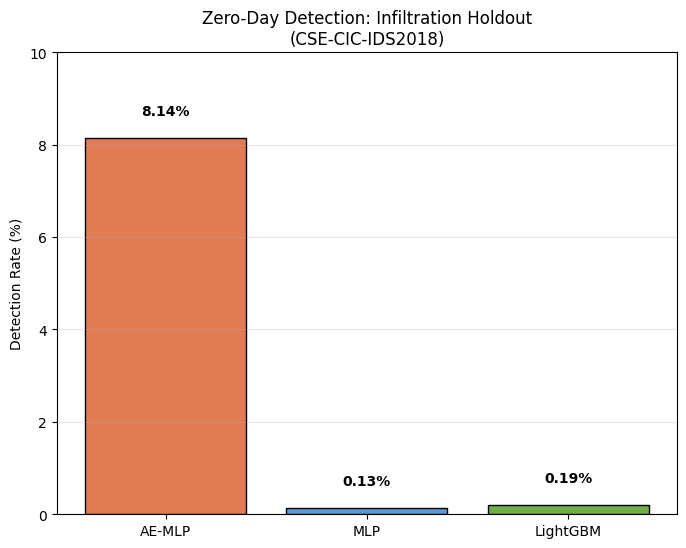

In [30]:
dr_inf = [8.14, 0.13, 0.19]
models = ['AE-MLP', 'MLP', 'LightGBM']
colors = ['#E07B54', '#5B9BD5', '#70AD47']
plt.figure(figsize=(8,6))
bars = plt.bar(models, dr_inf, color=colors, edgecolor='black')
plt.ylabel('Detection Rate (%)')
plt.title('Zero-Day Detection: Infiltration Holdout\n(CSE-CIC-IDS2018)')
for bar, val in zip(bars, dr_inf):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.2f}%', ha='center', fontweight='bold')
plt.ylim(0, 10)
plt.grid(axis='y', alpha=0.3)
plt.savefig(os.path.join(base, 'infiltration_holdout_barchart.png'), dpi=150)
plt.show()

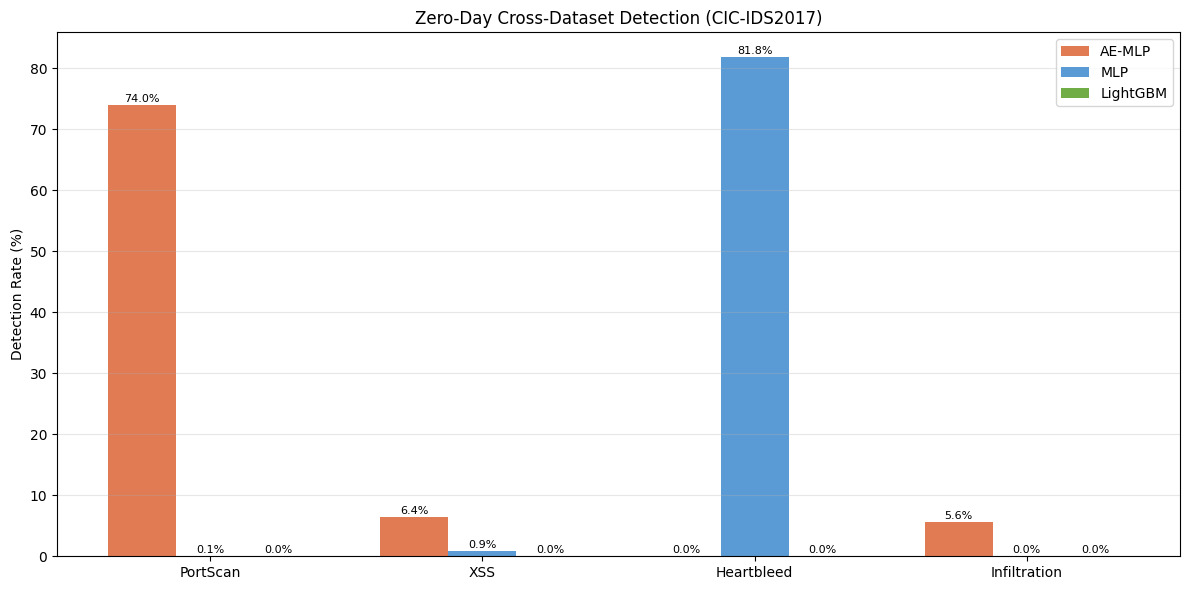

In [31]:
zero_day_attacks = df_results[df_results['Zero-Day (New Type)'] == 'Ya']
subset = zero_day_attacks[zero_day_attacks['Attack_Label'].isin(['PortScan', 'Heartbleed', 'Web Attack � XSS', 'Infiltration'])]
subset = subset.copy()
subset.loc[subset['Attack_Label'] == 'Web Attack � XSS', 'Attack_Label'] = 'XSS'
subset = subset.set_index('Attack_Label').reindex(['PortScan', 'XSS', 'Heartbleed', 'Infiltration'])
x = np.arange(len(subset))
width = 0.25
fig, ax = plt.subplots(figsize=(12,6))
ax.bar(x - width, subset['AE-MLP_DR%'], width, label='AE-MLP', color='#E07B54')
ax.bar(x, subset['MLP_DR%'], width, label='MLP', color='#5B9BD5')
ax.bar(x + width, subset['LightGBM_DR%'], width, label='LightGBM', color='#70AD47')
ax.set_xticks(x)
ax.set_xticklabels(subset.index)
ax.set_ylabel('Detection Rate (%)')
ax.set_title('Zero-Day Cross-Dataset Detection (CIC-IDS2017)')
ax.legend()
for i, (label, row) in enumerate(subset.iterrows()):
    ax.text(i - width, row['AE-MLP_DR%']+0.5, f"{row['AE-MLP_DR%']:.1f}%", ha='center', fontsize=8)
    ax.text(i, row['MLP_DR%']+0.5, f"{row['MLP_DR%']:.1f}%", ha='center', fontsize=8)
    ax.text(i + width, row['LightGBM_DR%']+0.5, f"{row['LightGBM_DR%']:.1f}%", ha='center', fontsize=8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(base, 'cross_dataset_zero_day_barchart.png'), dpi=150)
plt.show()

Infiltration DR: AE-MLP=8.14%, MLP=0.13%, LightGBM=0.19%


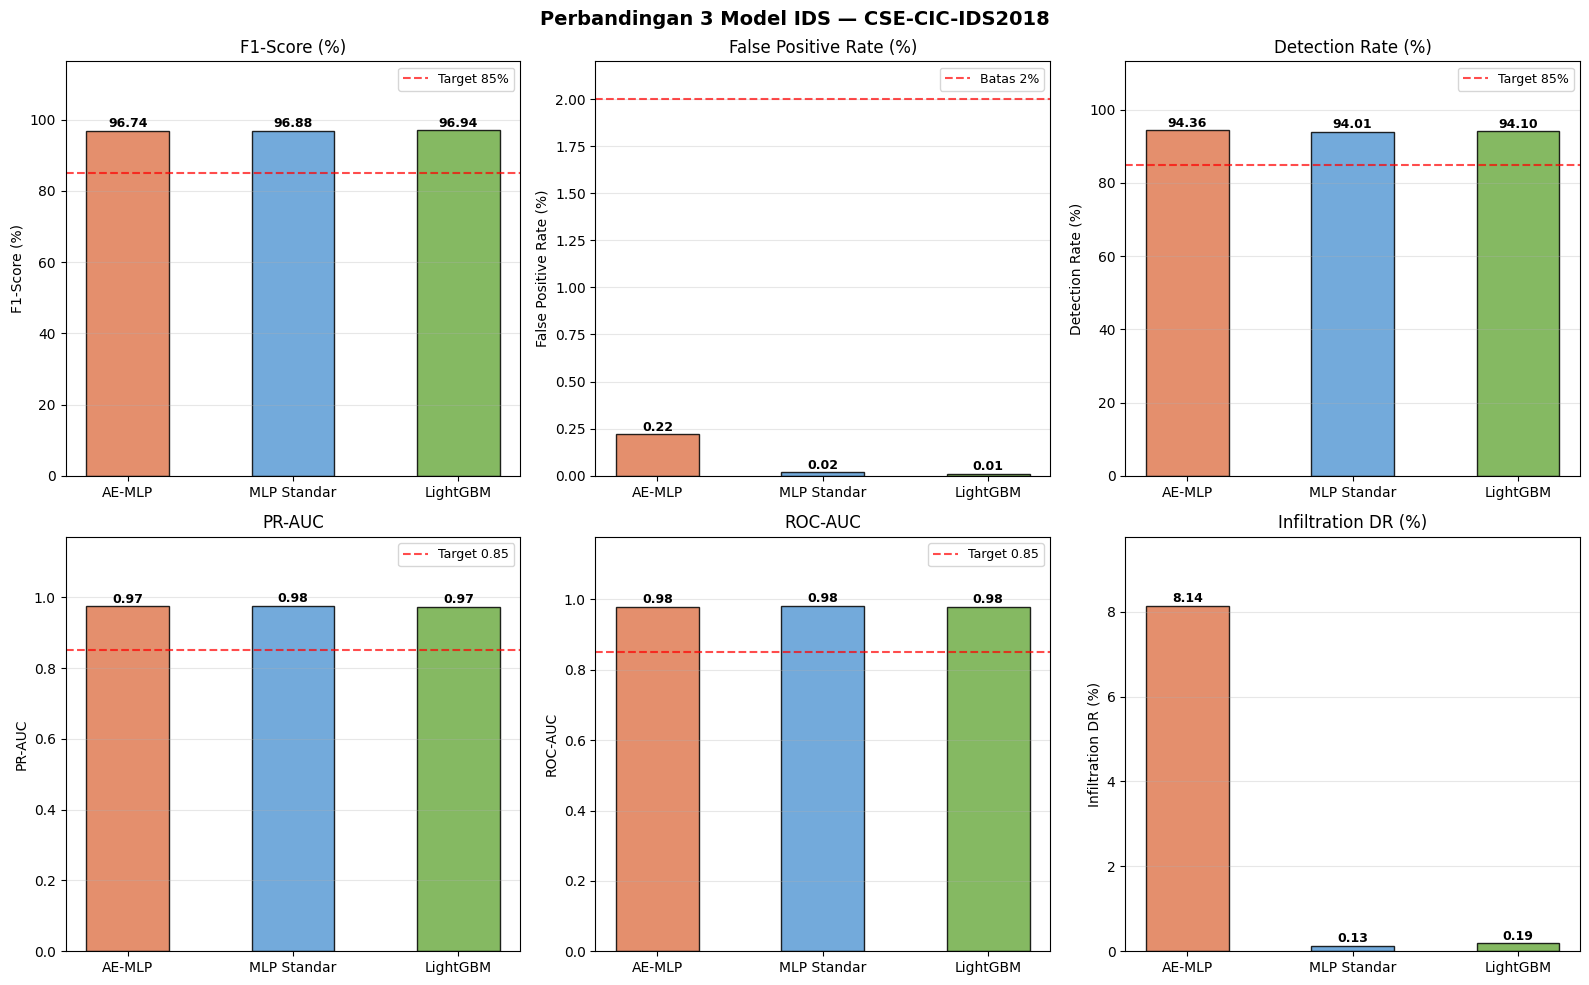

Grafik tersimpan: /content/drive/MyDrive/Colab Notebooks/comparison_3models.png


In [39]:
res_ae = joblib.load(os.path.join(MODEL_AE_PATH, 'results_ae.joblib'))
res_mlp = joblib.load(os.path.join(MODEL_MLP_PATH, 'results_mlp.joblib'))
res_lgbm = joblib.load(os.path.join(MODEL_LGBM_PATH, 'results_lgbm.joblib'))

dataset_split_path = os.path.join(base, "dataset_split.joblib")
if not os.path.exists(dataset_split_path):
    dataset_split_path = os.path.join(base, "dataset_split_.joblib")

data = joblib.load(dataset_split_path)
X_test = data['X_test'].astype('float32')
y_test = data['y_test']
lbl_test = data['label_test']

inf_mask = (lbl_test == 'Infiltration')
X_inf = X_test[inf_mask]

# AE-MLP
Z_inf = extract_latent_and_error(X_inf)
probs_ae = mlp_ae.predict(Z_inf, batch_size=256, verbose=0).ravel()
dr_ae = (probs_ae > THR_AE).mean() * 100

# MLP
probs_mlp = mlp_std.predict(X_inf, batch_size=256, verbose=0).ravel()
dr_mlp = (probs_mlp > THR_MLP).mean() * 100

# LightGBM
probs_lgbm = lgbm.predict_proba(X_inf)[:, 1]
dr_lgbm = (probs_lgbm > THR_LGBM).mean() * 100

print(f"Infiltration DR: AE-MLP={dr_ae:.2f}%, MLP={dr_mlp:.2f}%, LightGBM={dr_lgbm:.2f}%")

df_compare = pd.DataFrame([
    {
        'Model': 'AE-MLP',
        'F1 (%)': res_ae['f1'],
        'FPR (%)': res_ae['fpr'],
        'Recall (%)': res_ae['recall'],
        'PR-AUC': res_ae['pr_auc'],
        'ROC-AUC': res_ae['roc_auc'],
        'Infiltration DR': dr_ae,
    },
    {
        'Model': 'MLP Standar',
        'F1 (%)': res_mlp['f1'],
        'FPR (%)': res_mlp['fpr'],
        'Recall (%)': res_mlp['recall'],
        'PR-AUC': res_mlp['pr_auc'],
        'ROC-AUC': res_mlp['roc_auc'],
        'Infiltration DR': dr_mlp,
    },
    {
        'Model': 'LightGBM',
        'F1 (%)': res_lgbm['f1'],
        'FPR (%)': res_lgbm['fpr'],
        'Recall (%)': res_lgbm['recall'],
        'PR-AUC': res_lgbm['pr_auc'],
        'ROC-AUC': res_lgbm['roc_auc'],
        'Infiltration DR': dr_lgbm,
    }
])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
models = df_compare['Model'].tolist()
colors = ['#E07B54', '#5B9BD5', '#70AD47']
x = np.arange(len(models))

metrics = [
    ('F1 (%)', 'F1-Score (%)', 85, 'Target 85%'),
    ('FPR (%)', 'False Positive Rate (%)', 2, 'Batas 2%'),
    ('Recall (%)', 'Detection Rate (%)', 85, 'Target 85%'),
    ('PR-AUC', 'PR-AUC', 0.85, 'Target 0.85'),
    ('ROC-AUC', 'ROC-AUC', 0.85, 'Target 0.85'),
    ('Infiltration DR', 'Infiltration DR (%)', 0, None),
]

for ax, (col, label, ref, ref_label) in zip(axes.flat, metrics):
    vals = df_compare[col].tolist()
    bars = ax.bar(x, vals, color=colors, alpha=0.85, edgecolor='black', width=0.5)
    if ref_label:
        ax.axhline(y=ref, color='red', linestyle='--', alpha=0.7, label=ref_label)
        ax.legend(fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.002*max(max(vals), 1),
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10)
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(max(vals)*1.2, ref*1.1 if ref else 1))

plt.suptitle('Perbandingan 3 Model IDS — CSE-CIC-IDS2018',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(base, 'comparison_3models.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Grafik tersimpan: {save_path}')

In [41]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

In [42]:
SAMPLE_SIZE = 200_000
_, sample_idx = train_test_split(
    np.arange(len(X_test)),
    test_size=SAMPLE_SIZE,
    stratify=lbl_test,
    random_state=42
)
X_sample = X_test[sample_idx]
y_sample = y_test[sample_idx]
print(f"Ukuran sampel: {len(X_sample):,} (stratified)")

Ukuran sampel: 200,000 (stratified)


In [43]:
print("Menghitung probabilitas AE-MLP...")
Z_sample = extract_latent_and_error(X_sample, batch_size=4096)
probs_ae = mlp_ae.predict(Z_sample, batch_size=4096, verbose=0).ravel()

print("Menghitung probabilitas MLP...")
probs_mlp = mlp_std.predict(X_sample, batch_size=4096, verbose=0).ravel()

print("Menghitung probabilitas LightGBM...")
probs_lgbm = lgbm.predict_proba(X_sample)[:, 1]

Menghitung probabilitas AE-MLP...
Menghitung probabilitas MLP...
Menghitung probabilitas LightGBM...


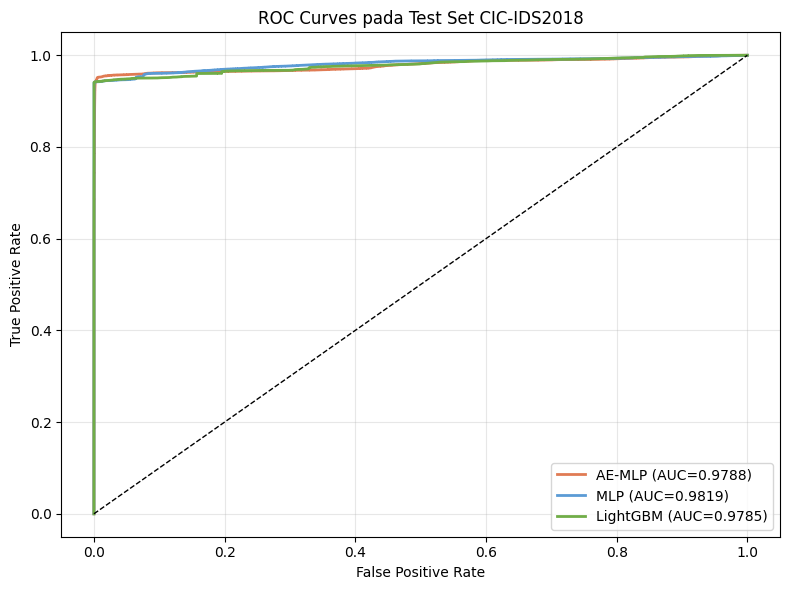

In [44]:
plt.figure(figsize=(8,6))
for name, probs, color in [('AE-MLP', probs_ae, '#E07B54'),
                           ('MLP', probs_mlp, '#5B9BD5'),
                           ('LightGBM', probs_lgbm, '#70AD47')]:
    fpr, tpr, _ = roc_curve(y_sample, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.4f})', color=color, lw=2)
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves pada Test Set CIC-IDS2018')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(base, 'roc_curves_all_models.png'), dpi=150)
plt.show()

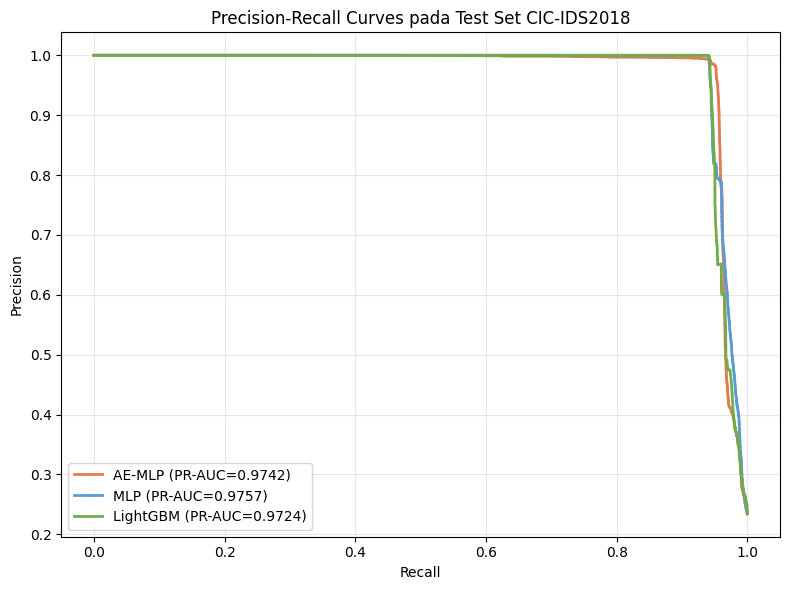

In [45]:
plt.figure(figsize=(8,6))
for name, probs, color in [('AE-MLP', probs_ae, '#E07B54'),
                           ('MLP', probs_mlp, '#5B9BD5'),
                           ('LightGBM', probs_lgbm, '#70AD47')]:
    prec, rec, _ = precision_recall_curve(y_sample, probs)
    pr_auc = auc(rec, prec)
    plt.plot(rec, prec, label=f'{name} (PR-AUC={pr_auc:.4f})', color=color, lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves pada Test Set CIC-IDS2018')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(base, 'pr_curves_all_models.png'), dpi=150)
plt.show()

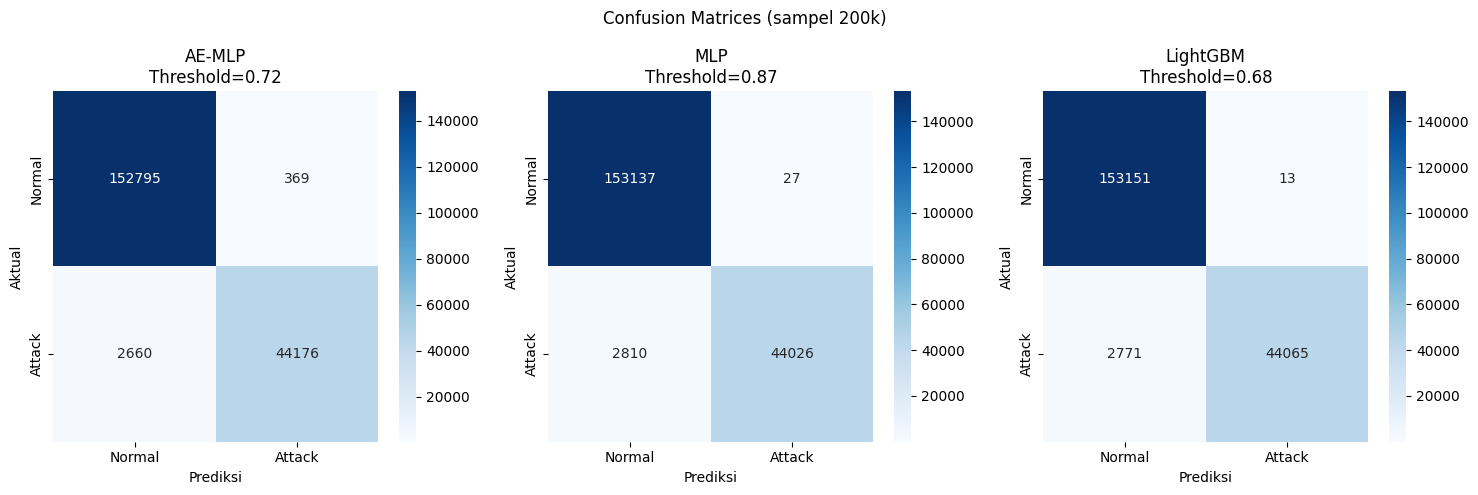

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
thr_dict = {'AE-MLP': THR_AE, 'MLP': THR_MLP, 'LightGBM': THR_LGBM}
prob_dict = {'AE-MLP': probs_ae, 'MLP': probs_mlp, 'LightGBM': probs_lgbm}
for ax, (name, thr) in zip(axes, thr_dict.items()):
    y_pred = (prob_dict[name] > thr).astype(int)
    cm = confusion_matrix(y_sample, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal','Attack'],
                yticklabels=['Normal','Attack'],
                ax=ax)
    ax.set_title(f'{name}\nThreshold={thr:.2f}')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
plt.suptitle('Confusion Matrices (sampel 200k)')
plt.tight_layout()
plt.savefig(os.path.join(base, 'confusion_matrices_all_models.png'), dpi=150)
plt.show()

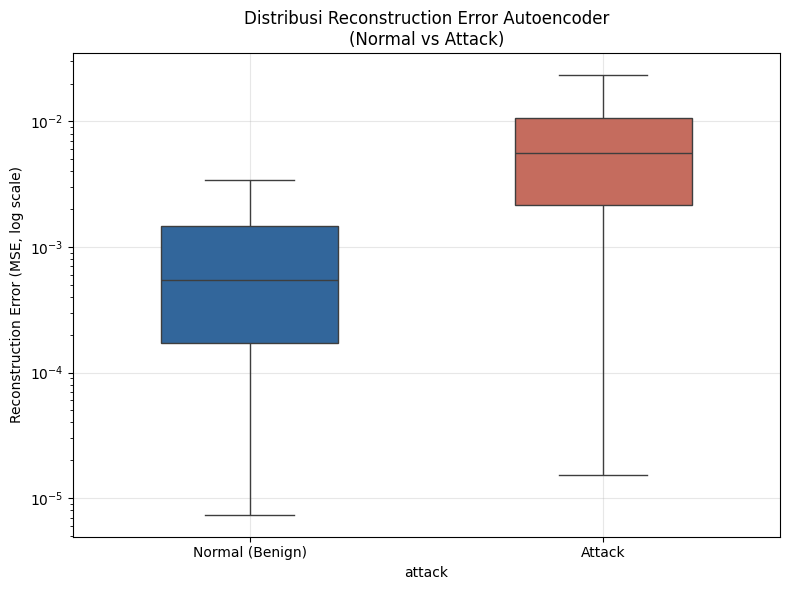

In [48]:
Z_sample_err = extract_latent_and_error(X_sample, batch_size=4096)
recon_err = Z_sample_err[:, 8]
df_recon = pd.DataFrame({'recon_error': recon_err, 'attack': y_sample})
plt.figure(figsize=(8,6))
sns.boxplot(x='attack', y='recon_error', data=df_recon,
            hue='attack', palette={0: '#2166AC', 1: '#D6604D'},
            legend=False, width=0.5, showfliers=False)
plt.xticks([0,1], ['Normal (Benign)', 'Attack'])
plt.yscale('log')
plt.ylabel('Reconstruction Error (MSE, log scale)')
plt.title('Distribusi Reconstruction Error Autoencoder\n(Normal vs Attack)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(base, 'reconstruction_error_boxplot.png'), dpi=150)
plt.show()

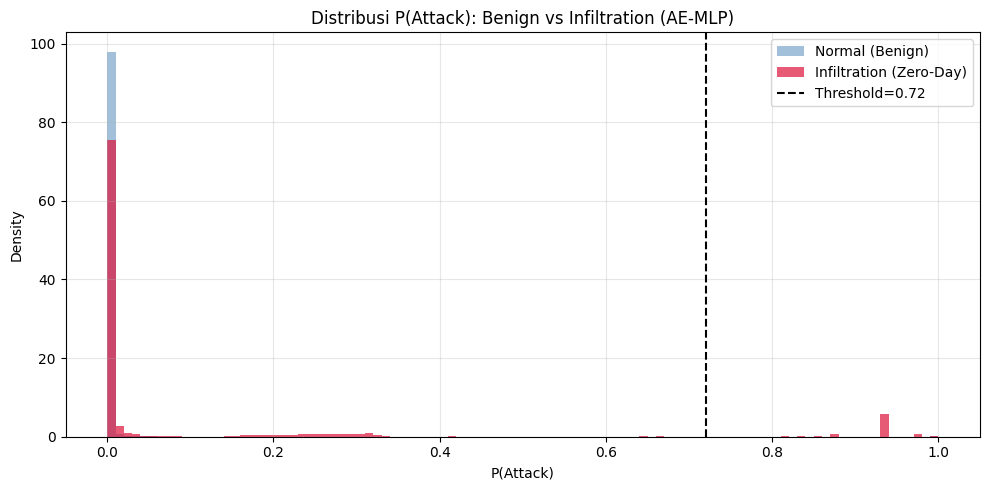

In [49]:
inf_mask = (lbl_test == 'Infiltration')
Z_inf_full = extract_latent_and_error(X_test[inf_mask], batch_size=4096)
probs_inf = mlp_ae.predict(Z_inf_full, batch_size=4096, verbose=0).ravel()
probs_norm = probs_ae[y_sample == 0]
plt.figure(figsize=(10,5))
plt.hist(probs_norm, bins=100, alpha=0.5, density=True, label='Normal (Benign)', color='steelblue')
plt.hist(probs_inf, bins=100, alpha=0.7, density=True, label='Infiltration (Zero-Day)', color='crimson')
plt.axvline(THR_AE, color='black', linestyle='--', label=f'Threshold={THR_AE:.2f}')
plt.xlabel('P(Attack)')
plt.ylabel('Density')
plt.title('Distribusi P(Attack): Benign vs Infiltration (AE-MLP)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(base, 'pattack_infiltration_histogram.png'), dpi=150)
plt.show()


 RECONSTRUCTION ERROR UNTUK SEMUA SERANGAN CIC-IDS2017

----------------------------------------------------------------------------------------------------
Tabel Lengkap Reconstruction Error & Detection Rate (CIC-IDS2017)
----------------------------------------------------------------------------------------------------
Attack Label                              Samples  Recon Error    Rasio  Det Rate(%)
----------------------------------------------------------------------------------------------------
PortScan                                  158,930     0.085599    50.65x        73.95%
DoS Hulk                                  231,073     0.070058    41.45x        30.15%
Infiltration                                   36     0.056663    33.53x         5.56%
Bot                                         1,966     0.055383    32.77x        59.51%
Heartbleed                                     11     0.039888    23.60x         0.00%
DDoS                                      128,027     

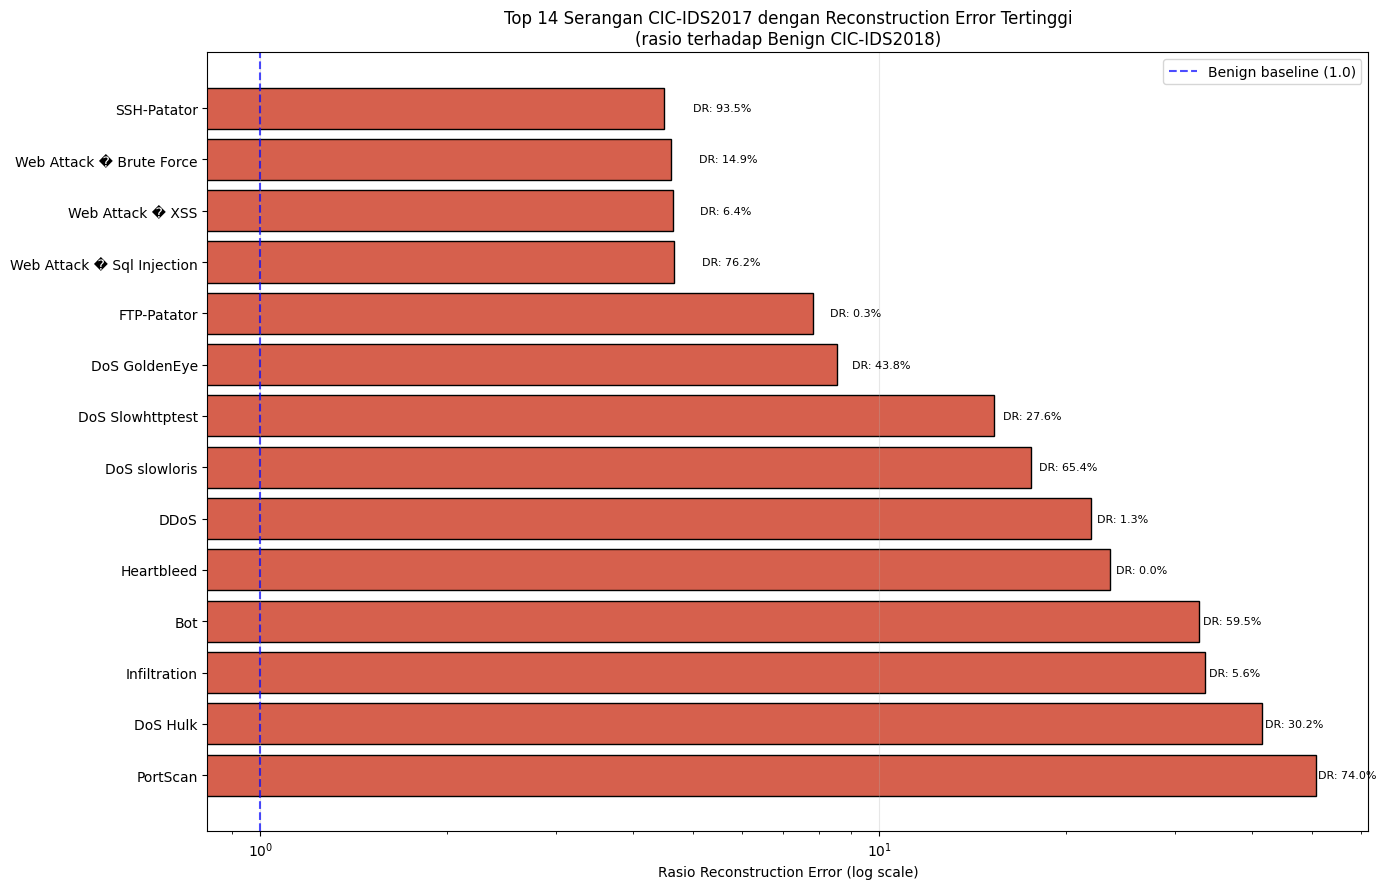

In [56]:
print("\n" + "="*70)
print(" RECONSTRUCTION ERROR UNTUK SEMUA SERANGAN CIC-IDS2017")
print("="*70)
err_benign = 0.001690

df_recon = df_results[['Attack_Label', 'Samples', 'AE-MLP_DR%', 'AE-MLP_ReconError']].copy()
df_recon = df_recon.rename(columns={
    'AE-MLP_ReconError': 'Recon_Error',
    'AE-MLP_DR%': 'Detection_Rate_%'
})
df_recon['Rasio_vs_Benign'] = df_recon['Recon_Error'] / err_benign
df_recon = df_recon.sort_values('Rasio_vs_Benign', ascending=False)

print("\n" + "-"*100)
print("Tabel Lengkap Reconstruction Error & Detection Rate (CIC-IDS2017)")
print("-"*100)
print(f"{'Attack Label':<40} {'Samples':>8} {'Recon Error':>12} {'Rasio':>8} {'Det Rate(%)':>12}")
print("-"*100)
for _, row in df_recon.iterrows():
    print(f"{row['Attack_Label']:<40} {row['Samples']:>8,} {row['Recon_Error']:>12.6f} {row['Rasio_vs_Benign']:>8.2f}x {row['Detection_Rate_%']:>12.2f}%")
print("-"*100)

csv_recon_path = os.path.join(base, 'reconstruction_error_cicids2017_all.csv')
df_recon.to_csv(csv_recon_path, index=False)
print(f"\nDisimpan ke {csv_recon_path}")

top_n = min(15, len(df_recon))
fig, ax = plt.subplots(figsize=(14, 9))
top_data = df_recon.head(top_n)
bars = ax.barh(top_data['Attack_Label'], top_data['Rasio_vs_Benign'], color='#D6604D', edgecolor='black')
ax.axvline(x=1, color='blue', linestyle='--', alpha=0.7, label='Benign baseline (1.0)')
ax.set_xlabel('Rasio Reconstruction Error (log scale)')
ax.set_xscale('log')
ax.set_title(f'Top {top_n} Serangan CIC-IDS2017 dengan Reconstruction Error Tertinggi\n(rasio terhadap Benign CIC-IDS2018)')
for bar, (idx, row) in zip(bars, top_data.iterrows()):
    dr_text = f"DR: {row['Detection_Rate_%']:.1f}%"
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, dr_text, va='center', fontsize=8)
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(base, 'reconstruction_error_cicids2017_top15_with_DR.png'), dpi=150)
plt.show()


 RECONSTRUCTION ERROR PADA TEST SET CIC-IDS2018
Menghitung reconstruction error...
Benign baseline error: 0.001693

--------------------------------------------------------------------------------
Tabel Reconstruction Error per Jenis Serangan (CIC-IDS2018 Test Set)
--------------------------------------------------------------------------------
Label                                Samples   Mean Error  Rasio vs Benign
--------------------------------------------------------------------------------
DDOS attack-LOIC-UDP                     260     0.051013           30.13x
DoS attacks-Slowloris                  1,648     0.033203           19.61x
FTP-BruteForce                        29,003     0.018521           10.94x
DoS attacks-SlowHTTPTest              20,983     0.018482           10.92x
DoS attacks-GoldenEye                  6,227     0.011130            6.57x
DDoS attacks-LOIC-HTTP                86,428     0.009273            5.48x
SSH-Bruteforce                        28,138  

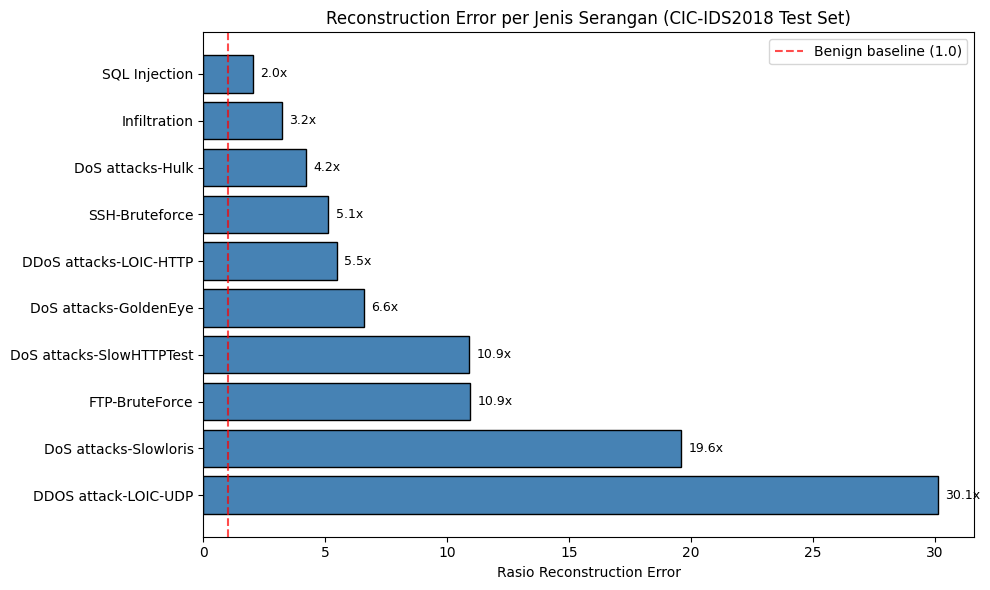

In [57]:
print("\n" + "="*70)
print(" RECONSTRUCTION ERROR PADA TEST SET CIC-IDS2018")
print("="*70)

print("Menghitung reconstruction error...")
X_pred_test = ae_model.predict(X_test, batch_size=4096, verbose=0)
recon_err = np.mean((X_test - X_pred_test) ** 2, axis=1)

err_benign = recon_err[y_test == 0].mean()
print(f"Benign baseline error: {err_benign:.6f}\n")

rows = []
for lbl in sorted(np.unique(lbl_test)):
    mask = (lbl_test == lbl)
    err_m = recon_err[mask].mean()
    ratio = err_m / err_benign
    n_samples = mask.sum()
    rows.append({
        'Label': lbl,
        'Samples': n_samples,
        'Mean_Error': err_m,
        'Rasio_vs_Benign': ratio
    })
df_recon_2018 = pd.DataFrame(rows).sort_values('Rasio_vs_Benign', ascending=False)

print("-"*80)
print("Tabel Reconstruction Error per Jenis Serangan (CIC-IDS2018 Test Set)")
print("-"*80)
print(f"{'Label':<35} {'Samples':>8} {'Mean Error':>12} {'Rasio vs Benign':>16}")
print("-"*80)
for _, row in df_recon_2018.iterrows():
    marker = " << ZERO-DAY" if row['Label'] == 'Infiltration' else ""
    print(f"{row['Label']:<35} {row['Samples']:>8,} {row['Mean_Error']:>12.6f} {row['Rasio_vs_Benign']:>15.2f}x{marker}")

csv_2018_path = os.path.join(base, 'reconstruction_error_cicids2018_testset.csv')
df_recon_2018.to_csv(csv_2018_path, index=False)
print(f"\nDisimpan ke {csv_2018_path}")

top10 = df_recon_2018.head(10)
plt.figure(figsize=(10,6))
bars = plt.barh(top10['Label'], top10['Rasio_vs_Benign'], color='steelblue', edgecolor='black')
plt.axvline(x=1, color='red', linestyle='--', alpha=0.7, label='Benign baseline (1.0)')
plt.xlabel('Rasio Reconstruction Error')
plt.title('Reconstruction Error per Jenis Serangan (CIC-IDS2018 Test Set)')
for bar, row in zip(bars, top10.iterrows()):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{row[1]['Rasio_vs_Benign']:.1f}x", va='center', fontsize=9)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(base, 'reconstruction_error_cicids2018_testset.png'), dpi=150)
plt.show()